## Benchmark Comparisons 

Comparing BMO, WOA, and MFO using six standard benchmarking functions

#### Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# np.random.seed(2025)

In [3]:
from WOA import WOA_test
from BMO import BMO

In [4]:
from benchmarking_functions import sphere, asap, rastrigin, griewank, shc, branin

#### Defining Benchmarking Bounds

In [5]:
# bounds for 6 benchmarking functions

# f1 - sphere bounds
sphere_lb = (-5.12)
sphere_ub = (5.12)

# f2 - asap bounds
asap_lb = (-5.12)
asap_ub = (5.12)

# f3 - rastrigin bounds
rastrigin_lb = (-5.12)
rastrigin_ub = (5.12)

# f4 - griewank bounds
griewank_lb = (-600)
griewank_ub = (600)

# f5 - six hump camel bounds
shc_lb = np.array(-5)
shc_ub = np.array(5)

# f6 - branin bounds
branin_lb = np.array([-5,  0])
branin_ub = np.array([10, 15])

shc_boundsW = (shc_lb, shc_ub)


In [6]:
# bounds for BMO for 6 benchmarking functions
sphere_bounds    = (-5.12, 5.12)
asap_bounds      = (-5.12, 5.12)
rastrigin_bounds = (-5.12, 5.12)
griewank_bounds  = (-600, 600)
shc_bounds = [(-3, 3), (-2, 2)]
branin_bounds = [(-5, 10), (0, 15)]

#### BMO

In [7]:
def run_multiple_BMO(obj_fn, dim, bounds, runs=30):
    ''' Runs BMO 30 times
    
        Parameters:
            obj_fn: objective function
            dim: dimensions
            bounds: lower and upper bounds
            runs: amount of times ran, set at 30
            
        Returns:
            Mean of best values: average best values 
            Std. Dev. of best values: standard deviation of best values
            best_values: list of best values
            avg_history: average convergence curve
            std_history: standard deviation of convergence curve'''
    
    # store best values and histories
    best_values = []
    histories = []

    # run BMO for the set amount of runs, define parameters
    for r in range(runs):
        best_sol, best_fit, history = BMO(
            obj_fn=obj_fn,
            dim=dim,
            bounds=bounds,
            pop_size=50,
            max_gens=500,
            seed=2025
        )
        # add best values and histories to list as alg runs
        best_values.append(best_fit)
        histories.append(history)

    # convert to array for averaging
    # shape: (runs, max_gens)
    histories = np.array(histories)   

    # take average and std dev across runs
    avg_history = histories.mean(axis=0)
    std_history = histories.std(axis=0)

    return (
        np.mean(best_values), 
        np.std(best_values), 
        best_values,
        avg_history,
        std_history
    )


In [8]:
def evaluate_and_plot(name, func, dim, bounds, run_multiples):
    ''' Returns mean and standard deviation of best values across 30 runs of BMO
    
        Parameters:
            name: name of objective function
            func: objective_function
            dim: dimensionality
            bounds: lower and upper bounds
            run_multiples: run multiple functions for each algorithm
            
        Returns:
            mean_val: mean value of values
            std_val: standard deviation of values
            convergence plots, one for each objective function'''
    
    # processing 
    print(f"\nRunning 30 runs for {name}...")

    # apply run_multiple BMO function 
    mean_val, std_val, runs_vals, avg_hist, std_hist = run_multiples(
        func, dim, bounds, runs=30
    )

    # printing mean fitness and standard deviation fitness
    print(f"{name} Mean Fitness: {mean_val}")
    print(f"{name} Std Dev     : {std_val}")

    # plot convergence 
    plt.figure(figsize=(7,5))
    plt.plot(avg_hist, label="Average Convergence")
    plt.title(f"BMO Convergence Curve: {name}")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
evaluate_and_plot("Sphere (f1)", sphere, 30, sphere_bounds,run_multiple_BMO)
evaluate_and_plot("Absolute Sum & Absolute Product (f2)", asap, 30, asap_bounds,run_multiple_BMO)
evaluate_and_plot("Rastrigin (f3)", rastrigin, 30, rastrigin_bounds,run_multiple_BMO)
evaluate_and_plot("Griewank (f4)", griewank, 30, griewank_bounds,run_multiple_BMO)

evaluate_and_plot("Six-Hump Camel (f5)", shc, 2, shc_bounds,run_multiple_BMO)
evaluate_and_plot("Branin (f6)", branin, 2, branin_bounds,run_multiple_BMO)



Running 30 runs for Sphere (f1)...


KeyboardInterrupt: 

#### WOA

In [23]:
from WOA import WOA_test

In [24]:
def run_multiple_WOA(obj_fn, dim, bounds, runs=30):
    ''' Runs WOA 30 times
    
        Parameters:
            obj_fn: objective function
            dim: dimensions
            bounds: lower and upper bounds
            runs: amount of times ran, set at 30
            
        Returns:
            Mean of best values: average best values 
            Std. Dev. of best values: standard deviation of best values
            best_values: list of best values
            avg_history: average convergence curve
            std_history: standard deviation of convergence curve'''
    
    # best fitness values from each run
    best_values = []
    # list of best fitness values over time 
    histories = []

    # bounds
    lb, ub = bounds  

    # loop for set amount of runs
    for r in range(runs):
        # WOA paran=meters
        best_pos, history = WOA_test(
            f=obj_fn,
            dim=dim,
            lb=lb,
            ub=ub,
            num_whales=30,
            max_iter=500,
            seed=2025
        )

        # best fitness 
        final_best = history[-1]    
        # store best fitness values and histories for each iter   
        best_values.append(final_best)
        histories.append(history)

    # convert to array to take mean and sd 
    histories = np.array(histories)    

    # avg and sd of best fitness for iter i in 30 runs
    avg_history = histories.mean(axis=0)
    std_history = histories.std(axis=0)

    return (
        np.mean(best_values),
        np.std(best_values),
        best_values,
        avg_history,
        std_history
    )


In [25]:
def evaluate_and_plot_WOA(name, func, dim, bounds, run_multiples):
    ''' Returns mean and standard deviation of best values across 30 runs of BMO
    
        Parameters:
            name: name of objective function
            func: objective_function
            dim: dimensionality
            bounds: lower and upper bounds
            run_multiples: run multiple functions for each algorithm
            
        Returns:
            mean_val: mean value of values
            std_val: standard deviation of values
            convergence plots, one for each objective function'''
    
    # processing 
    print(f"\nRunning 30 runs for {name}...")

    # apply run_multiple BMO function 
    mean_val, std_val, runs_vals, avg_hist, std_hist = run_multiples(
        func, dim, bounds, runs=30
    )

    # printing mean fitness and standard deviation fitness
    print(f"{name} Mean Fitness: {mean_val}")
    print(f"{name} Std Dev     : {std_val}")

    # plot convergence 
    plt.figure(figsize=(7,5))
    plt.plot(avg_hist, label="Average Convergence")
    plt.title(f"WOA Convergence Curve: {name}")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



Running 30 runs for Sphere (f1)...
Sphere (f1) Mean Fitness: 1.4937506471228996e-88
Sphere (f1) Std Dev     : 2.7904965607477417e-104


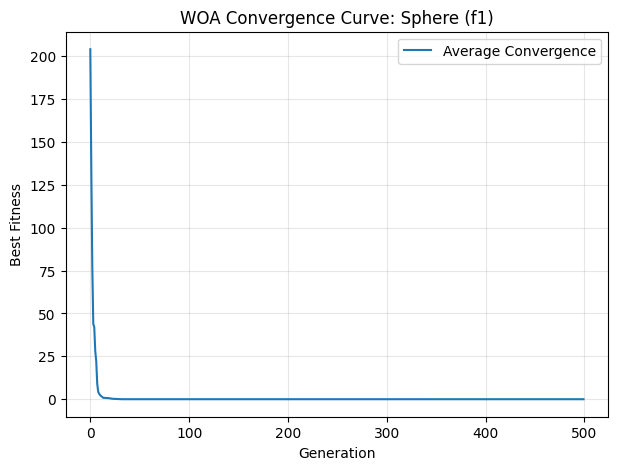


Running 30 runs for Absolute Sum & Absolute Product (f2)...
Absolute Sum & Absolute Product (f2) Mean Fitness: 2.2507842569631215e-57
Absolute Sum & Absolute Product (f2) Std Dev     : 0.0


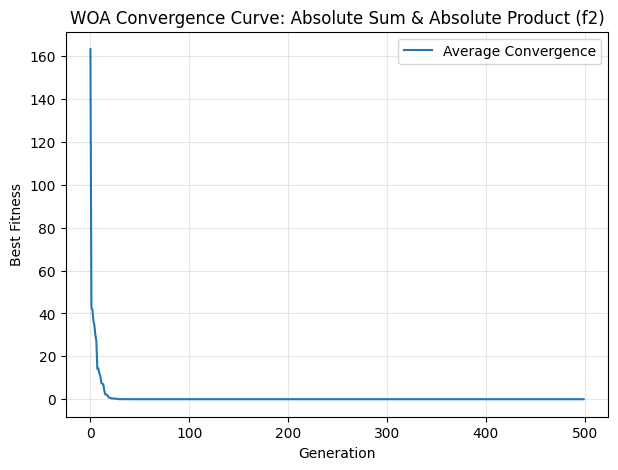


Running 30 runs for Rastrigin (f3)...
Rastrigin (f3) Mean Fitness: 0.0
Rastrigin (f3) Std Dev     : 0.0


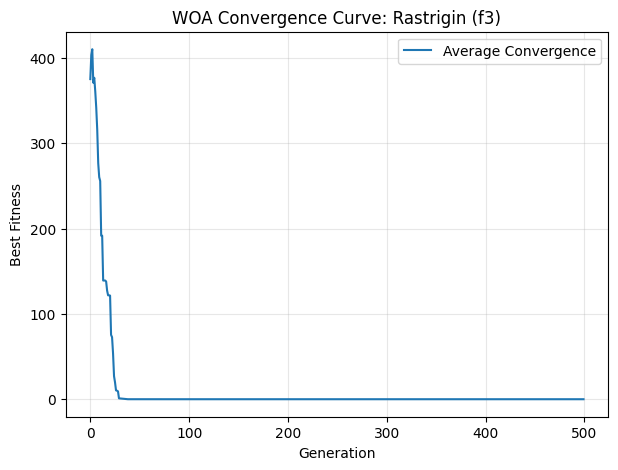


Running 30 runs for Griewank (f4)...
Griewank (f4) Mean Fitness: 0.0
Griewank (f4) Std Dev     : 0.0


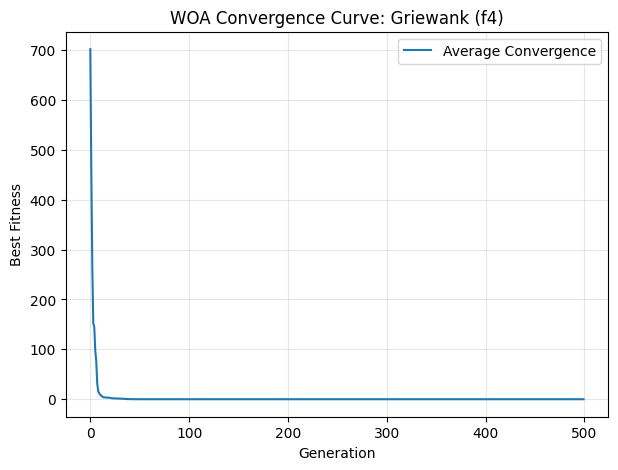


Running 30 runs for Six-Hump Camel (f5)...
Six-Hump Camel (f5) Mean Fitness: -1.0316284532816777
Six-Hump Camel (f5) Std Dev     : 2.220446049250313e-16


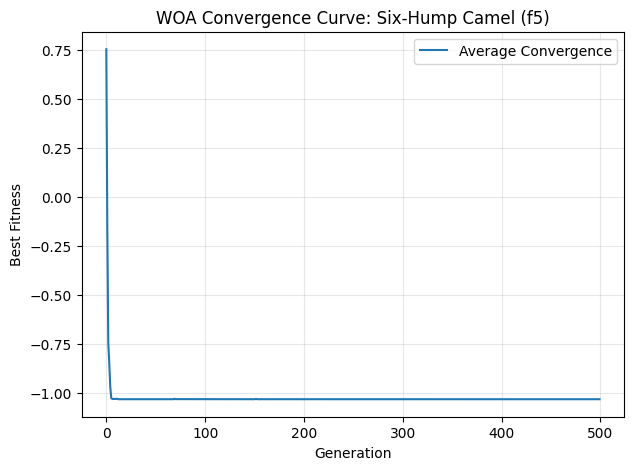


Running 30 runs for Branin (f6)...
Branin (f6) Mean Fitness: 0.39800625470719275
Branin (f6) Std Dev     : 0.0


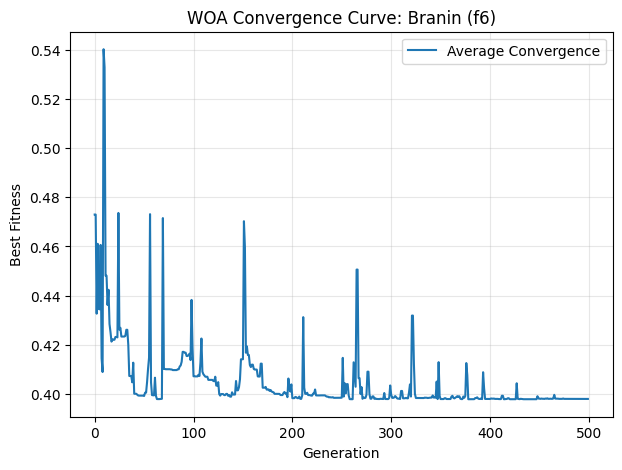

In [26]:
evaluate_and_plot_WOA("Sphere (f1)", sphere, 30, sphere_bounds,run_multiple_WOA)
evaluate_and_plot_WOA("Absolute Sum & Absolute Product (f2)", asap, 30, asap_bounds,run_multiple_WOA)
evaluate_and_plot_WOA("Rastrigin (f3)", rastrigin, 30, rastrigin_bounds,run_multiple_WOA)
evaluate_and_plot_WOA("Griewank (f4)", griewank, 30, griewank_bounds,run_multiple_WOA)

evaluate_and_plot_WOA("Six-Hump Camel (f5)", shc, 2, shc_boundsW,run_multiple_WOA)
evaluate_and_plot_WOA("Branin (f6)", branin, 2, branin_bounds,run_multiple_WOA)


#### MFO

In [27]:
from MFO import moth_flame_optimization

In [40]:
def run_multiple_MFO(obj_fn, dim, bounds, runs=30):
    ''' Runs MFO 30 times
    
        Parameters:
            obj_fn: objective function
            dim: dimensions
            bounds: lower and upper bounds
            runs: amount of times ran, set at 30
            
        Returns:
            Mean of best values: average best values 
            Std. Dev. of best values: standard deviation of best values
            best_values: list of best values
            avg_history: average convergence curve
            std_history: standard deviation of convergence curve'''
    
    # best fitness values from each run
    best_values = []
    # list of best fitness values over time 
    histories = []

    # bounds
    #lb, ub = bounds  

    # loop for set amount of runs
    for r in range(runs):
        # MFO paran=meters
        best_pos, best_score, history = moth_flame_optimization(
            obj_func=obj_fn,
            dim=dim,
            bounds=bounds,
            n_moths=30,
            n_iters=500,
            b = 1.0,
            seed=2025
        )

        # add best values and histories to list as alg runs
        best_values.append(best_score)
        histories.append(history)

    # convert to array for averaging
    # shape: (runs, max_gens)
    histories = np.array(histories)   

    # take average and std dev across runs
    avg_history = histories.mean(axis=0)
    std_history = histories.std(axis=0)

    return (
        np.mean(best_values), 
        np.std(best_values), 
        best_values,
        avg_history,
        std_history
    )


In [43]:
def evaluate_and_plot(name, func, dim, bounds, run_multiples):
    ''' Returns mean and standard deviation of best values across 30 runs of MFO
    
        Parameters:
            name: name of objective function
            func: objective_function
            dim: dimensionality
            bounds: lower and upper bounds
            run_multiples: run multiple functions for each algorithm
            
        Returns:
            mean_val: mean value of values
            std_val: standard deviation of values
            convergence plots, one for each objective function'''
    
    # processing 
    print(f"\nRunning 30 runs for {name}...")

    # apply run_multiple MFO function 
    mean_val, std_val, runs_vals, avg_hist, std_hist = run_multiples(
        func, dim, bounds, runs=30
    )

    # printing mean fitness and standard deviation fitness
    print(f"{name} Mean Fitness: {mean_val}")
    print(f"{name} Std Dev     : {std_val}")

    # plot convergence 
    plt.figure(figsize=(7,5))
    plt.plot(avg_hist, label="Average Convergence")
    plt.title(f"MFO Convergence Curve: {name}")
    plt.xlabel("Iteration")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



Running 30 runs for Sphere (f1)...
Sphere (f1) Mean Fitness: 0.08192513237565135
Sphere (f1) Std Dev     : 0.0


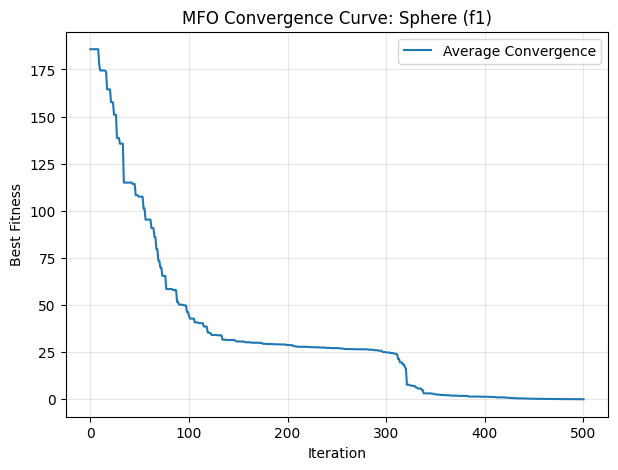


Running 30 runs for Absolute Sum & Absolute Product (f2)...
Absolute Sum & Absolute Product (f2) Mean Fitness: 5.439328207899736
Absolute Sum & Absolute Product (f2) Std Dev     : 0.0


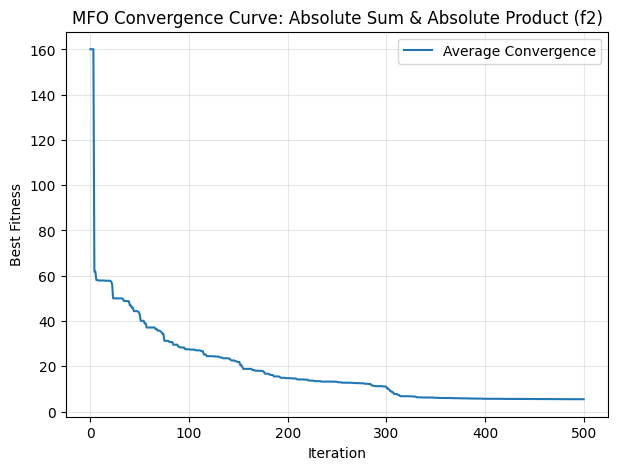


Running 30 runs for Rastrigin (f3)...
Rastrigin (f3) Mean Fitness: 250.09208246803968
Rastrigin (f3) Std Dev     : 0.0


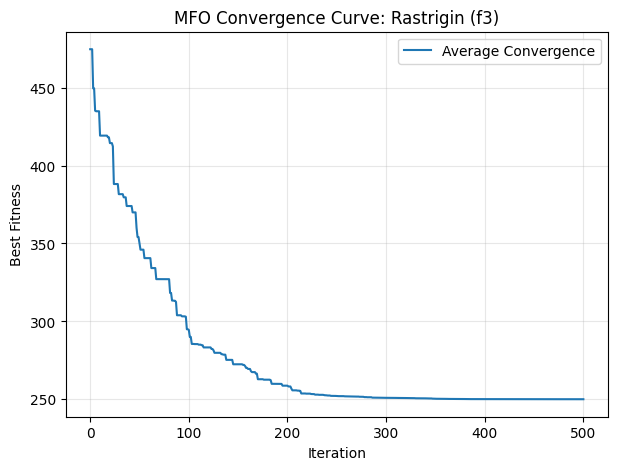


Running 30 runs for Griewank (f4)...
Griewank (f4) Mean Fitness: 1.2812667297690206
Griewank (f4) Std Dev     : 4.440892098500626e-16


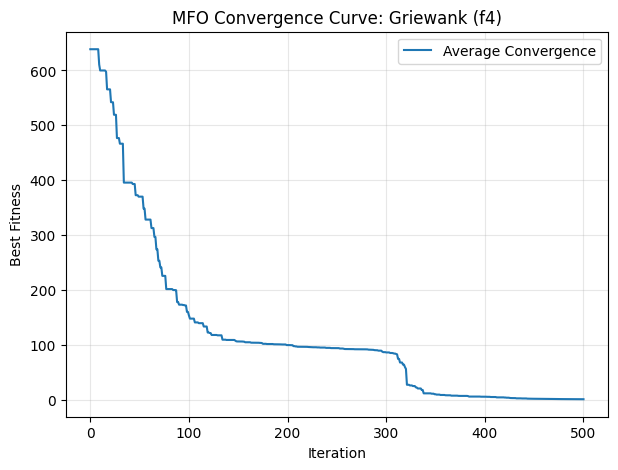


Running 30 runs for Six-Hump Camel (f5)...
Six-Hump Camel (f5) Mean Fitness: -1.0316284534898774
Six-Hump Camel (f5) Std Dev     : 4.440892098500626e-16


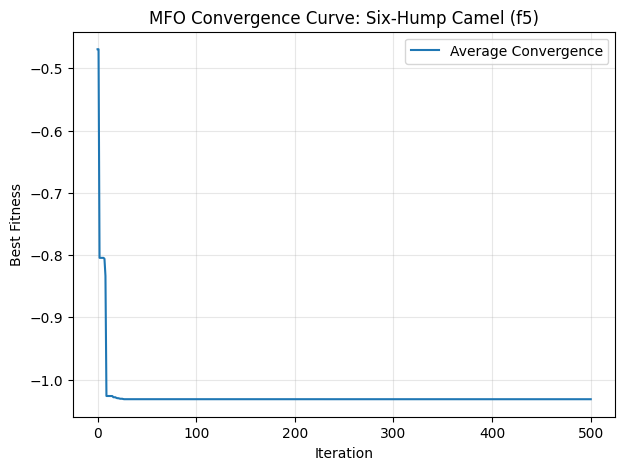


Running 30 runs for Branin (f6)...
Branin (f6) Mean Fitness: 0.39788735772973816
Branin (f6) Std Dev     : 0.0


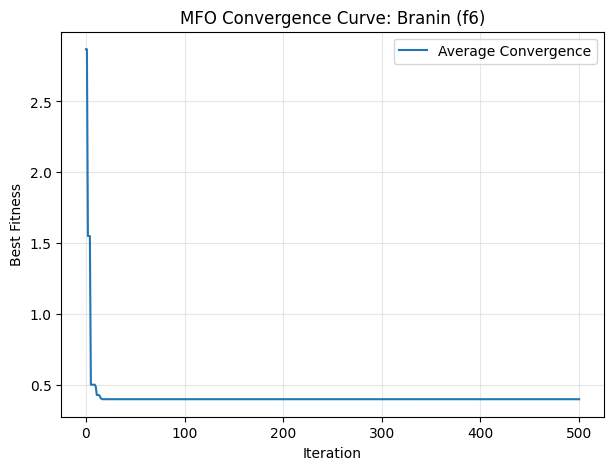

In [ ]:
evaluate_and_plot("Sphere (f1)", sphere, 30, sphere_bounds,run_multiple_MFO)
evaluate_and_plot("Absolute Sum & Absolute Product (f2)", asap, 30, asap_bounds,run_multiple_MFO)
evaluate_and_plot("Rastrigin (f3)", rastrigin, 30, rastrigin_bounds,run_multiple_MFO)
evaluate_and_plot("Griewank (f4)", griewank, 30, griewank_bounds,run_multiple_MFO)

evaluate_and_plot("Six-Hump Camel (f5)", shc, 2, shc_bounds,run_multiple_MFO)
evaluate_and_plot("Branin (f6)", branin, 2, branin_bounds,run_multiple_MFO)
